In [1]:
import nbimporter  # type: ignore





# =============================================================================
#
# Pronostico time trend + fourier seasonal
#
# =============================================================================

#
# Carga de datos
#

import functions  # type: ignore

df_orig = functions.load_data()
df_orig.head()







,yt_true
date,
1946-01-01,890
1946-02-01,992
1946-03-01,979
1946-04-01,959
1946-05-01,1110


In [2]:

#
# Componentes de tendencia lineal
#
df_orig = functions.add_linear_trend_component(df_orig)
df_orig = functions.add_month_component(df_orig)
df_orig.head()








,yt_true,trend,month
date,,,
1946-01-01,890,0,1
1946-02-01,992,1,2
1946-03-01,979,2,3
1946-04-01,959,3,4
1946-05-01,1110,4,5


In [3]:

#
# Fourier
#
df_orig = functions.add_sin_cos_components(df_orig)
df_orig.head(15)



#








,yt_true,trend,month,sin_12m,cos_12m,sin_6m,cos_6m,sin_4m,cos_4m,sin_3m,cos_3m
date,,,,,,,,,,,
1946-01-01,890,0,1,5.000000e-01,8.660254e-01,8.660254e-01,0.5,1.000000e+00,6.123234e-17,8.660254e-01,-0.5
1946-02-01,992,1,2,8.660254e-01,5.000000e-01,8.660254e-01,-0.5,1.224647e-16,-1.000000e+00,-8.660254e-01,-0.5
1946-03-01,979,2,3,1.000000e+00,6.123234e-17,1.224647e-16,-1.0,-1.000000e+00,-1.836970e-16,-2.449294e-16,1.0
1946-04-01,959,3,4,8.660254e-01,-5.000000e-01,-8.660254e-01,-0.5,-2.449294e-16,1.000000e+00,8.660254e-01,-0.5
1946-05-01,1110,4,5,5.000000e-01,-8.660254e-01,-8.660254e-01,0.5,1.000000e+00,3.061617e-16,-8.660254e-01,-0.5
1946-06-01,1546,5,6,1.224647e-16,-1.000000e+00,-2.449294e-16,1.0,3.673940e-16,-1.000000e+00,-4.898587e-16,1.0
1946-07-01,1539,6,7,-5.000000e-01,-8.660254e-01,8.660254e-01,0.5,-1.000000e+00,-4.286264e-16,8.660254e-01,-0.5
1946-08-01,3401,7,8,-8.660254e-01,-5.000000e-01,8.660254e-01,-0.5,-4.898587e-16,1.000000e+00,-8.660254e-01,-0.5
1946-09-01,2092,8,9,-1.000000e+00,-1.836970e-16,3.673940e-16,-1.0,1.000000e+00,5.510911e-16,-7.347881e-16,1.0


In [4]:



#
# Particionamiento de los datos
#
(
    X_complete,
    y_complete,
    X_train,
    y_train,
    X_test,
    y_test,
) = functions.train_test_split(
    df=df_orig,
    x_columns=[
        "trend",
        "sin_12m",
        "cos_12m",
        "sin_6m",
        "cos_6m",
        "sin_4m",
        "cos_4m",
        "sin_3m",
        "cos_3m",
    ],
    y_column="yt_true",
)










In [5]:


  #
  # Especificación del modelo
  #
  from sklearn.compose import ColumnTransformer  # type: ignore
  from sklearn.linear_model import LinearRegression  # type: ignore
  from sklearn.pipeline import Pipeline  # type: ignore
  from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures  # type: ignore

  pipeline = Pipeline(
      [
          (
              "preprocessor",
              ColumnTransformer(
                  [
                      (
                          "trend",
                          Pipeline(
                              [
                                  ("poly", PolynomialFeatures(degree=3)),
                                  ("scaler", MinMaxScaler()),
                              ]
                          ),
                          ["trend"],
                      ),
                  ],
                  remainder="passthrough",
              ),
          ),
          ("regressor", LinearRegression()),
      ]
  )



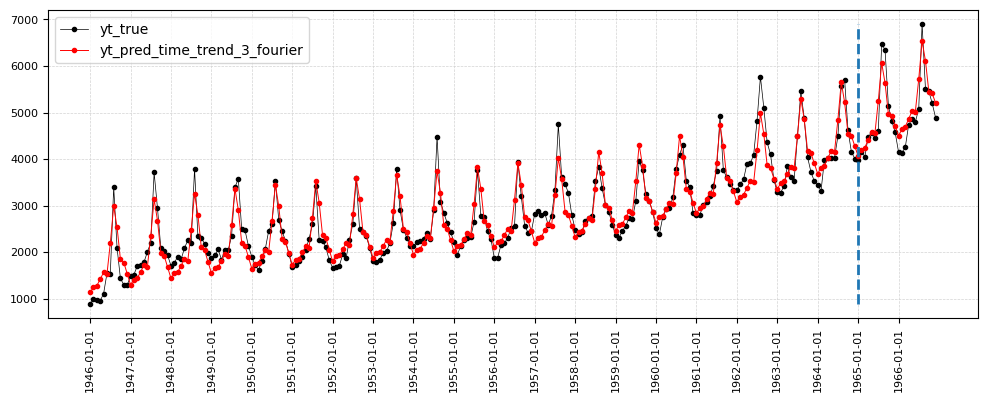

In [8]:


#
# Entrenamiento y pronostico
#
pipeline.fit(X_train, y_train)
df_orig["yt_pred_time_trend_3_fourier"] = pipeline.predict(X_complete)
functions.plot_time_series(df_orig)


In [9]:


#
# Almacenamiento de los resultados
#
functions.save_forecasts(df_orig)



In [10]:
#
# Construcción de la matriz de regresores
#

df_orig = functions.make_lagged_ts(
    df=df_orig,
    p_max=13,
    y_column="yt_true",
    fmt="lagged_{}m",
)
df_orig.head()



,yt_true,trend,month,sin_12m,cos_12m,sin_6m,cos_6m,sin_4m,cos_4m,sin_3m,...,lagged_4m,lagged_5m,lagged_6m,lagged_7m,lagged_8m,lagged_9m,lagged_10m,lagged_11m,lagged_12m,lagged_13m
date,,,,,,,,,,,,,,,,,,,,,
1946-01-01,890,0,1,0.500000,8.660254e-01,8.660254e-01,0.5,1.000000e+00,6.123234e-17,8.660254e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-02-01,992,1,2,0.866025,5.000000e-01,8.660254e-01,-0.5,1.224647e-16,-1.000000e+00,-8.660254e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-03-01,979,2,3,1.000000,6.123234e-17,1.224647e-16,-1.0,-1.000000e+00,-1.836970e-16,-2.449294e-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-04-01,959,3,4,0.866025,-5.000000e-01,-8.660254e-01,-0.5,-2.449294e-16,1.000000e+00,8.660254e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-05-01,1110,4,5,0.500000,-8.660254e-01,-8.660254e-01,0.5,1.000000e+00,3.061617e-16,-8.660254e-01,...,890.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
#
# Remoción de los valores faltantes
#
df_dropna = df_orig.dropna()




In [12]:
#
# División de los datos en entrenamiento y prueba
#
(
    X_complete,
    y_complete,
    X_train,
    y_train,
    X_test,
    y_test,
) = functions.train_test_split(
    df=df_dropna,
    x_columns=[f"lagged_{i}m" for i in range(1, 13)],
    y_column="yt_true",
)


In [15]:

#
# Pronostico usando una red neuronal tipo MLP
#
from sklearn.neural_network import MLPRegressor  # type: ignore


def create_pipeline(hidden):

    return MLPRegressor(
        hidden_layer_sizes=(hidden,),
        activation="logistic",
        learning_rate="adaptive",
        momentum=0.01,
        learning_rate_init=0.2,
        max_iter=10000,
        random_state=123456,
    )

C:\Users\intel\AppData\Local\Temp\ipykernel_17180\3240899313.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dropna[f"yt_pred_mlp_{hidden}"] = pipeline.predict(X_complete)


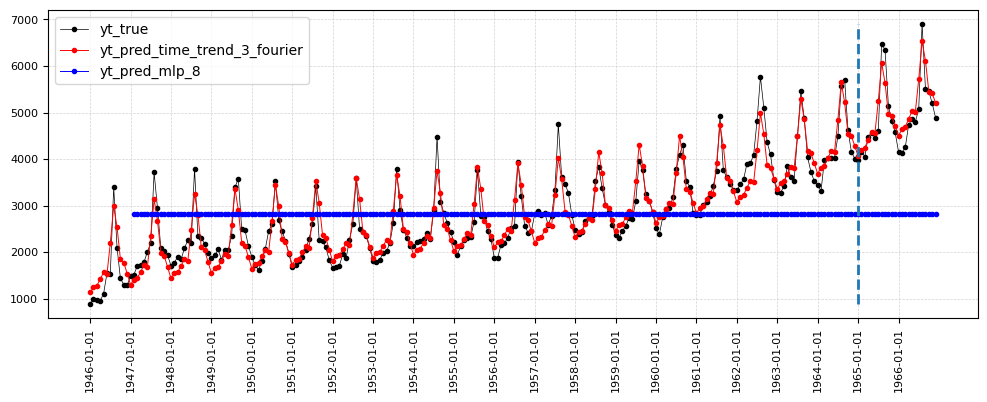

In [16]:

#
# Entrenamiento y pronostico
#
hidden = 8
pipeline = create_pipeline(hidden=hidden)
pipeline.fit(X_train, y_train)
df_dropna[f"yt_pred_mlp_{hidden}"] = pipeline.predict(X_complete)
df_orig.loc[df_dropna.index, f"yt_pred_mlp_{hidden}"] = df_dropna[
    f"yt_pred_mlp_{hidden}"
]

functions.plot_time_series(df=df_orig, yt_col="yt_true")
